# LUAD alleles → AnnData

Builds an AnnData object from the Caicedo CMVIP profiles in the [Cell Painting Gallery](https://broadinstitute.github.io/cellpainting-gallery/) (`cpg0031-caicedo-cmvip`, also known as LUAD, BBBC043).
One observation is a well, one variable is a CellProfiler feature.

A549 cells with overexpressed alleles of lung adenocarcinoma genes, sixteen plates.
The gallery quotes 596 alleles across 53 genes; the counts actually present in these profiles are printed below.
Because both wild-type and mutant alleles of the same gene are present, this dataset asks a sharper question than most: does a point mutation change cell morphology?
Profiles only, no images:

```bash
aws s3 cp --no-sign-request --recursive --exclude "*" --include "*_normalized_feature_select_batch.csv.gz" \
  s3://cellpainting-gallery/cpg0031-caicedo-cmvip/broad/workspace/profiles/ .
```

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import scanpy as sc

import cell_painting_io as cpio

PROFILES = Path("~/data/cpg0031-caicedo-cmvip/profiles").expanduser()

In [2]:
files = sorted(PROFILES.glob("*/*/*.csv.gz"))
adata = cpio.read_profiles(files, index_columns=("Plate", "Well"))
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_features(adata)
for column in ["Plate", "pert_type", "plate_map_name", "x_mutation_status"]:
    adata.obs[column] = adata.obs[column].astype("category")
adata

AnnData object with n_obs × n_vars = 6144 × 564
    obs: 'NCBIGeneID', 'pert_type', 'plate_map_name', 'PublicID', 'Transcript', 'VirusPlateName', 'x_mutation_status', 'broad_sample', 'pert_name', 'Plate', 'Well', 'Site_Count', 'Count_Cells', 'Count_CellsIncludingEdges', 'Count_Cytoplasm', 'Count_Nuclei', 'Count_NucleiIncludingEdges', 'Object_Count'
    var: 'compartment', 'family', 'channel', 'channel_2', 'n_channels'
    layers: None (.X)

## Sanity checks

`pert_type` separates overexpression from the vector and empty controls.

In [3]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features across {adata.obs['Plate'].nunique()} plates")
print(f"alleles: {adata.obs['pert_name'].nunique()} | genes: {adata.obs['NCBIGeneID'].nunique()}")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())}")
print(adata.obs["pert_type"].value_counts().to_string())
print(adata.obs["x_mutation_status"].value_counts(dropna=False).head().to_string())

6,144 wells x 564 features across 16 plates
alleles: 594 | genes: 135
non-finite: 0
pert_type
trt_oe        5312
ctl_vector     512
EMPTY          320
x_mutation_status
EMPTY         320
EGFP          136
BFP           128
HCRED         128
LUCIFERASE    120


In [4]:
adata.write_h5ad(PROFILES.parent / "luad_alleles.h5ad")

## UMAP

In [5]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
cpio.neighbour_enrichment(adata, ["Plate", "plate_map_name", "pert_type", "NCBIGeneID"])

,observed,baseline,ratio
covariate,,,
Plate,0.143,0.062,2.291
plate_map_name,0.745,0.500,1.489
pert_type,0.791,0.757,1.044
NCBIGeneID,0.141,0.038,3.723


Gene identity is the strongest structure, above plate — the opposite ordering to CPJUMP1 and EUbOPEN, and a good sign: wells overexpressing the same gene look alike.
The two plate maps separate cleanly, which is design rather than biology.
Overexpression versus control is nearly flat, unsurprising when 86% of wells are overexpression and the controls are a handful of fluorescent proteins.

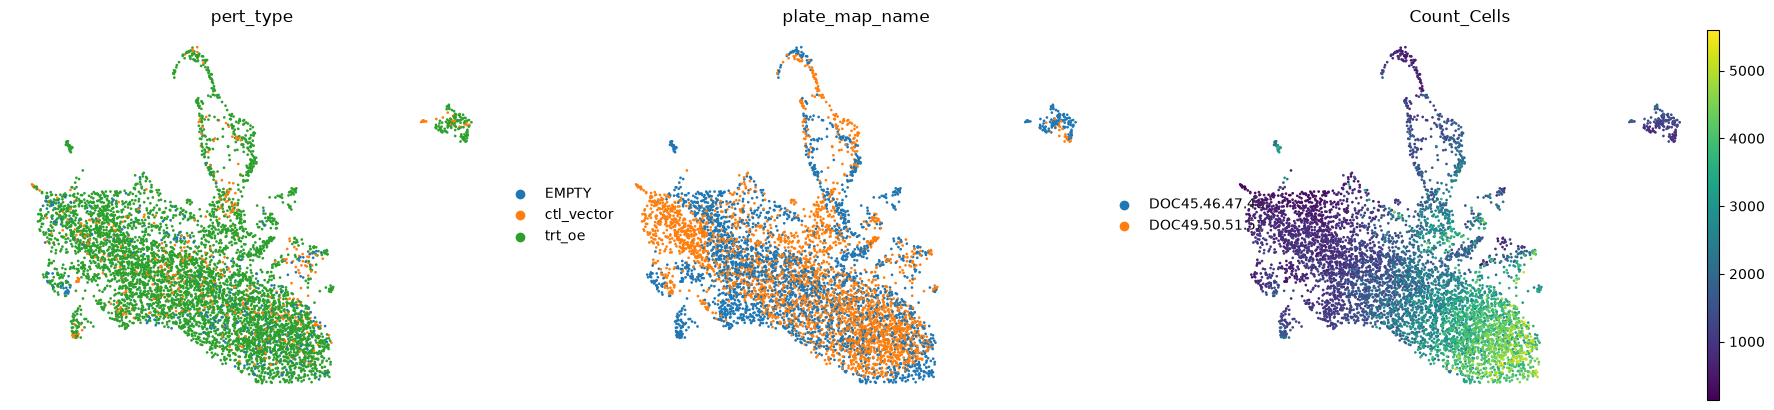

In [7]:
sc.pl.umap(adata, color=["pert_type", "plate_map_name", "Count_Cells"], ncols=3, frameon=False, size=15)